In [10]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
pd.set_option("display.max_columns", None) 
sns.set_style("whitegrid")

In [11]:
#2. Load Data
#Processed Dataset
fraud = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

fraud.head()
#EDA Dataset (Contains Country Column)
fraud_geo = pd.read_csv(
    "../data/processed/fraud_merged.csv"
)

fraud_geo.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country,time_since_signup,hour_of_day,day_of_week,transaction_count,device_transaction_count,prev_purchase,time_between_transactions
0,2,2015-01-11 03:47:13,2015-02-21 10:03:37,54,FGBQNDNBETFJJ,SEO,Chrome,F,25,880217484,0,8.724152e+08,8.891924e+08,United States,3564984.0,10,5,1,1,NaN,0.0
1,4,2015-06-02 16:40:57,2015-09-26 21:32:16,41,MKFUIVOHLJBYN,Direct,Safari,F,38,2785906106,0,2.785542e+09,2.786066e+09,Switzerland,10039879.0,21,5,1,1,NaN,0.0
2,8,2015-05-28 07:53:06,2015-08-13 11:53:07,47,SCQGQALXBUQZJ,SEO,Chrome,M,25,356056736,0,3.523215e+08,3.690988e+08,United States,6667201.0,11,3,1,1,NaN,0.0
3,12,2015-01-10 06:25:12,2015-03-04 20:56:37,35,MSNWCFEHKTIOY,Ads,Safari,M,19,2985180352,0,2.985034e+09,2.985296e+09,Mexico,4631485.0,20,2,1,1,NaN,0.0
4,16,2015-02-03 13:48:23,2015-03-12 12:46:23,9,FROZWSSWOHZBE,Direct,IE,M,32,578312545,0,5.704253e+08,5.872026e+08,United States,3193080.0,12,3,1,1,NaN,0.0


In [12]:
print("Shape:", fraud.shape)
fraud.info()
fraud.describe()

Shape: (129146, 204)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129146 entries, 0 to 129145
Columns: 204 entries, user_id to country_Zimbabwe
dtypes: bool(187), float64(9), int64(5), object(3)
memory usage: 39.8+ MB


,user_id,purchase_value,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,time_since_signup,hour_of_day,day_of_week,transaction_count,device_transaction_count,prev_purchase,time_between_transactions
count,129146.000000,1.291460e+05,1.291460e+05,1.291460e+05,129146.000000,1.291460e+05,1.291460e+05,1.291460e+05,129146.000000,129146.000000,129146.0,1.291460e+05,0.0,129146.0
mean,200130.920416,-1.152089e-16,-9.452189e-17,1.892795e+09,0.094993,1.890950e+09,1.894646e+09,-1.067360e-16,11.507333,3.013643,0.0,-1.980668e-17,NaN,0.0
std,115358.923526,1.000004e+00,1.000004e+00,1.085207e+09,0.293207,1.086802e+09,1.083635e+09,1.000004e+00,6.910243,2.007088,0.0,1.000004e+00,NaN,0.0
min,2.000000,-1.524887e+00,-1.756001e+00,1.677886e+07,0.000000,1.677824e+07,1.677926e+07,-1.574394e+00,0.000000,0.000000,0.0,-2.598744e-01,NaN,0.0
25%,100603.250000,-8.151916e-01,-7.113436e-01,9.561635e+08,0.000000,9.395241e+08,9.563013e+08,-8.777507e-01,6.000000,1.000000,0.0,-2.598744e-01,NaN,0.0
50%,199971.500000,-1.054965e-01,-1.490527e-02,1.899710e+09,0.000000,1.899708e+09,1.899733e+09,-6.163021e-04,12.000000,3.000000,0.0,-2.598744e-01,NaN,0.0
75%,299994.750000,6.587905e-01,6.815331e-01,2.832125e+09,0.000000,2.832073e+09,2.832138e+09,8.679339e-01,17.000000,5.000000,0.0,-2.598744e-01,NaN,0.0
max,400000.000000,6.390943e+00,4.976236e+00,3.758053e+09,1.000000,3.758031e+09,3.758064e+09,1.738463e+00,23.000000,6.000000,0.0,6.899521e+00,NaN,0.0


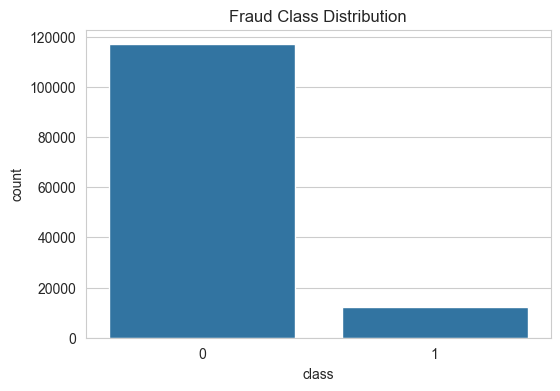

In [13]:
fraud["class"].value_counts()
fraud["class"].value_counts(normalize=True) * 100
plt.figure(figsize=(6,4))

sns.countplot(
    x="class",
    data=fraud
)

plt.title("Fraud Class Distribution")
plt.show()

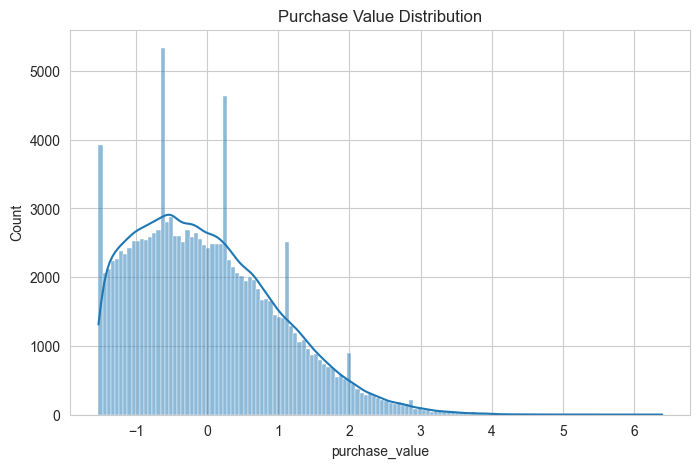

In [14]:
plt.figure(figsize=(8,5)) 
sns.histplot( fraud["purchase_value"], kde=True ) 
plt.title("Purchase Value Distribution") 
plt.show()

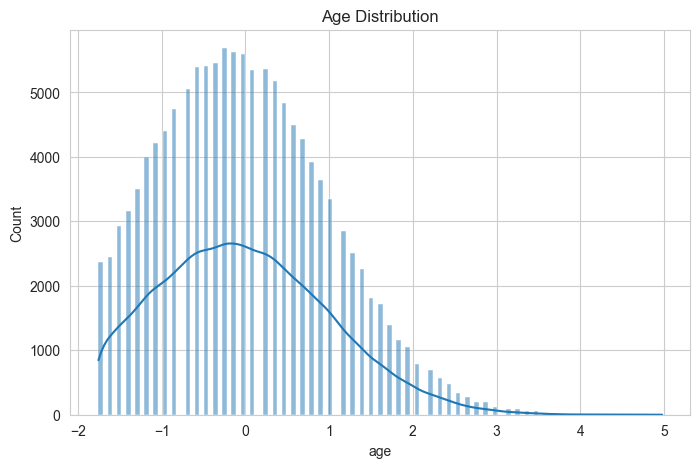

In [15]:
plt.figure(figsize=(8,5)) 
sns.histplot( fraud["age"], kde=True ) 
plt.title("Age Distribution") 
plt.show()

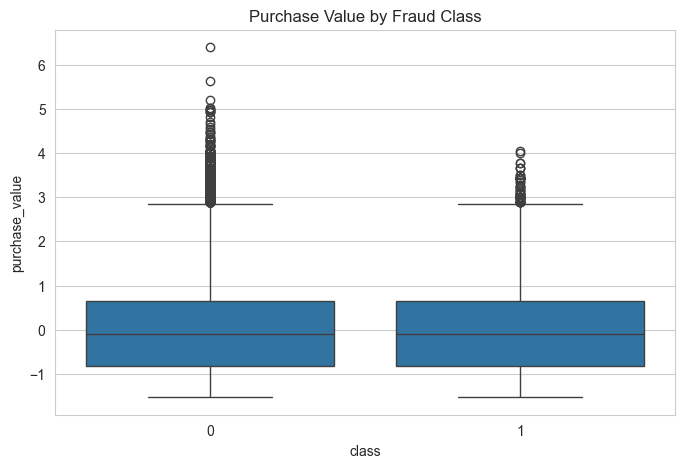

In [16]:
plt.figure(figsize=(8,5)) 
sns.boxplot( x="class", y="purchase_value", data=fraud ) 
plt.title("Purchase Value by Fraud Class") 
plt.show()

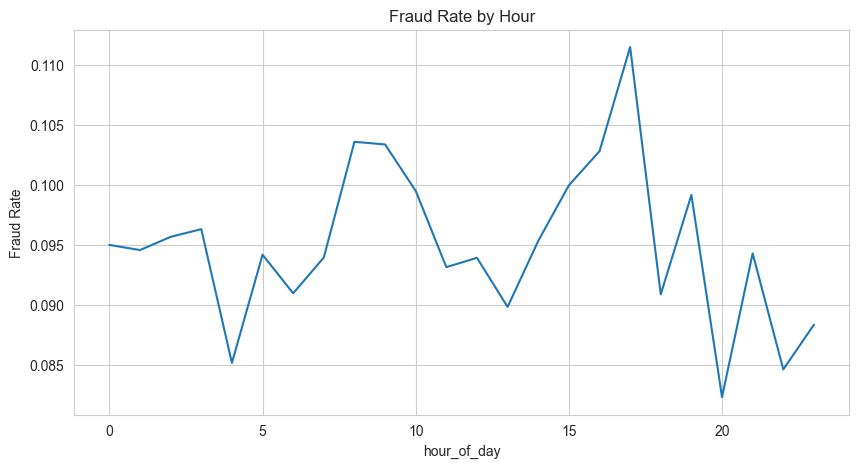

In [17]:
hourly_fraud = (
    fraud_geo.groupby("hour_of_day")["class"]
    .mean()
)

hourly_fraud.plot(
    kind="line",
    figsize=(10,5)
)

plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Rate")
plt.show()

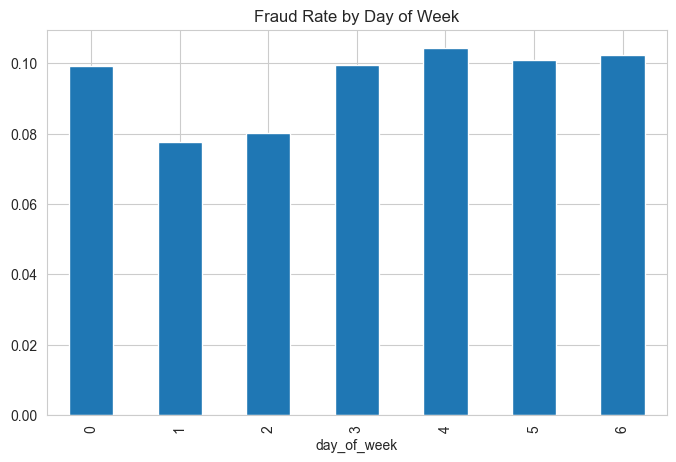

In [18]:
daily_fraud = ( fraud_geo.groupby("day_of_week")["class"] .mean() ) 
daily_fraud.plot( kind="bar", figsize=(8,5) ) 
plt.title("Fraud Rate by Day of Week") 
plt.show()

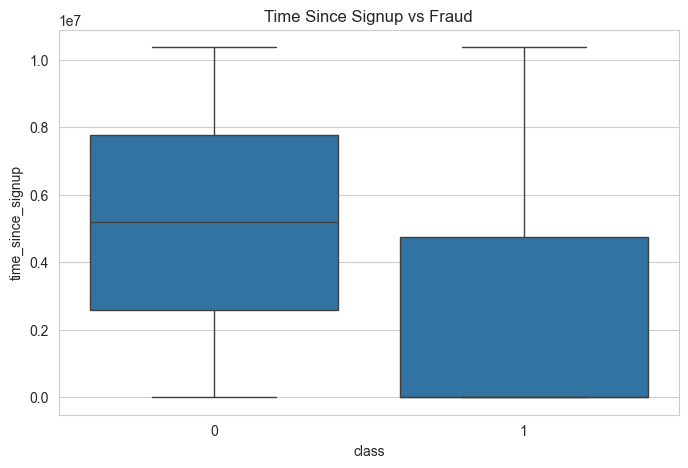

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="class",
    y="time_since_signup",
    data=fraud_geo
)

plt.title("Time Since Signup vs Fraud")
plt.show()

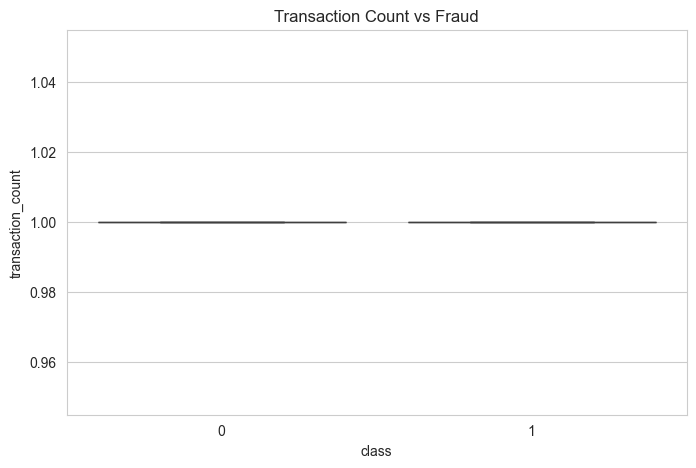

In [20]:
plt.figure(figsize=(8,5)) 
sns.boxplot( x="class", y="transaction_count", data=fraud_geo ) 
plt.title("Transaction Count vs Fraud") 
plt.show()

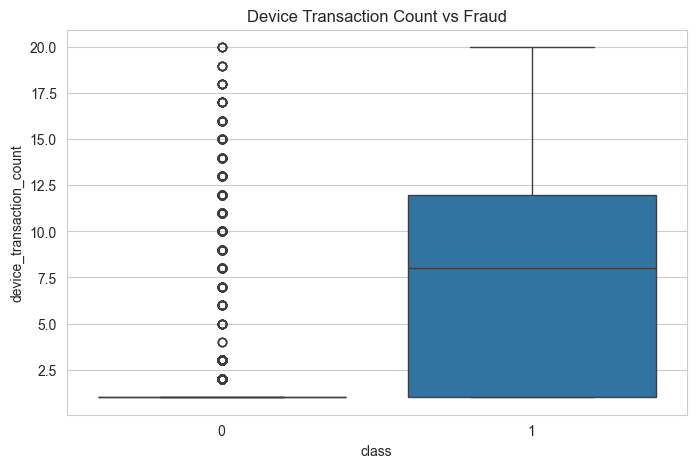

In [21]:
plt.figure(figsize=(8,5)) 
sns.boxplot( x="class", y="device_transaction_count", data=fraud_geo ) 
plt.title("Device Transaction Count vs Fraud") 
plt.show()

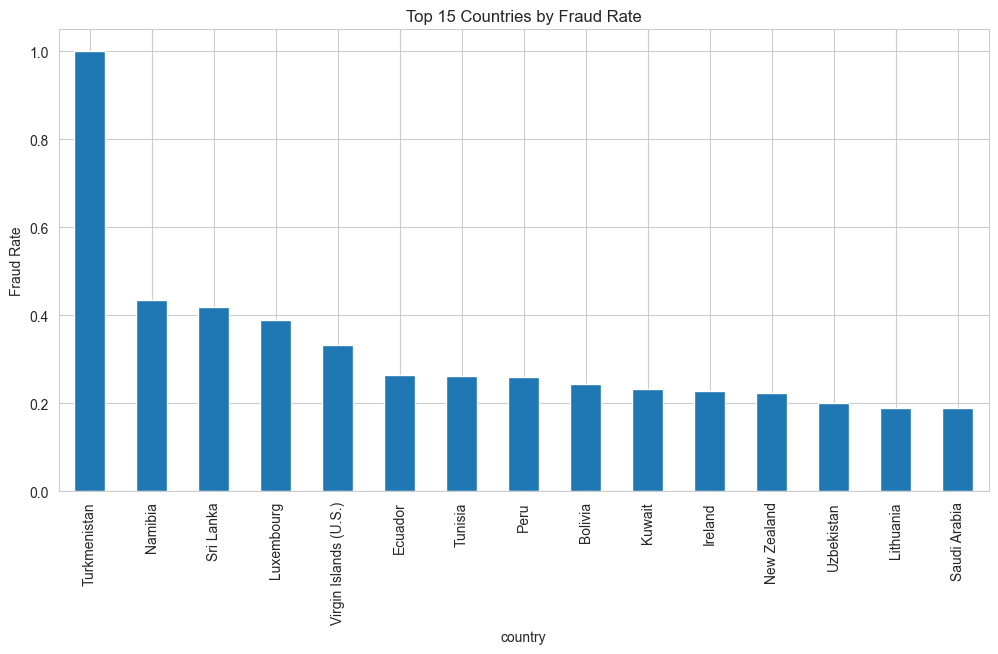

In [22]:
country_fraud = (
    fraud_geo.groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

country_fraud.plot(kind="bar")

plt.title("Top 15 Countries by Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()

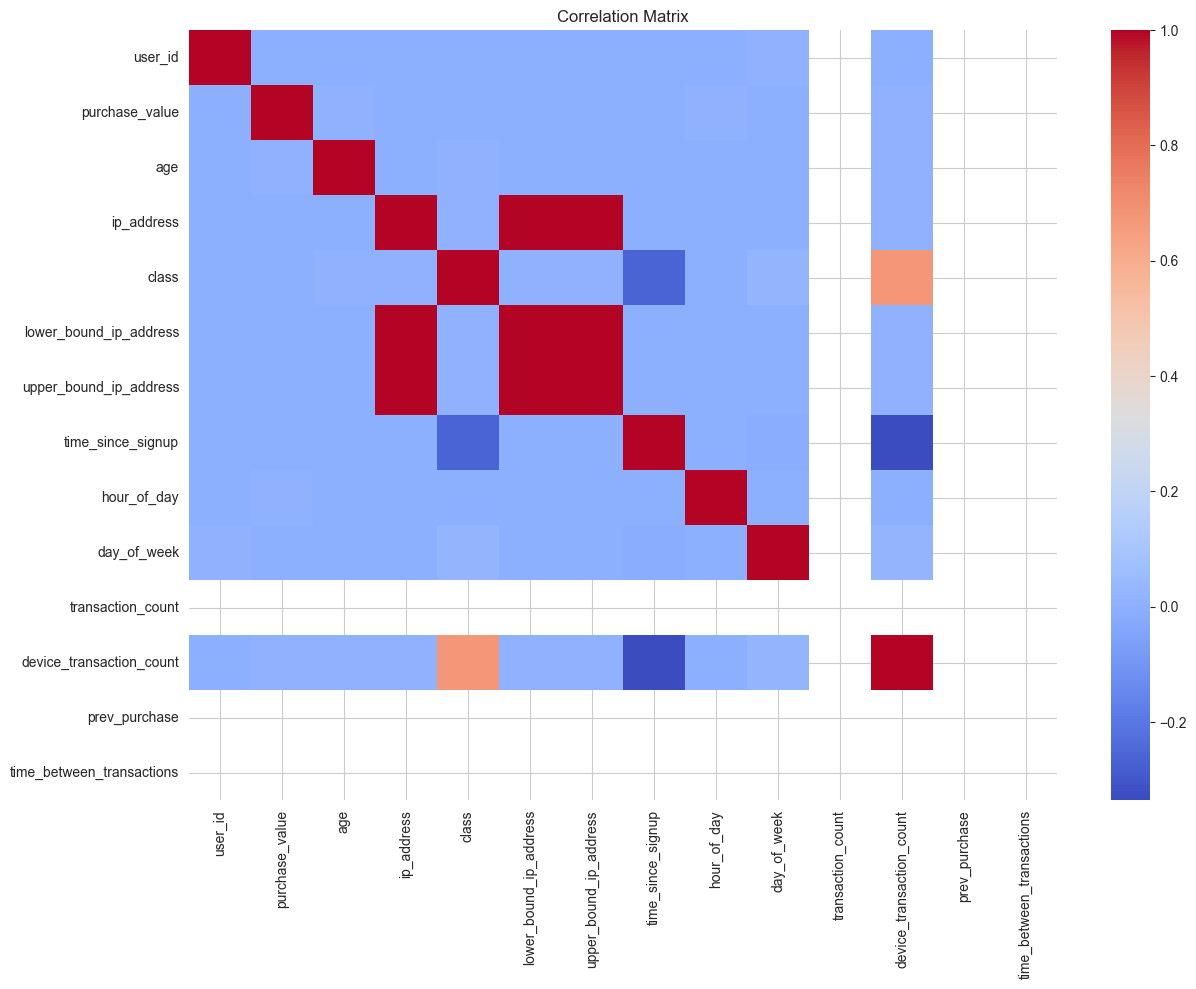

In [23]:
corr = fraud.select_dtypes( include=np.number ).corr() 
plt.figure(figsize=(14,10)) 
sns.heatmap( corr, cmap="coolwarm" ) 
plt.title("Correlation Matrix") 
plt.show()